In [8]:
import pandas as pd
df=pd.read_csv("news_data.csv")

df.head()
print(df.columns)
print(df["subject"].unique())
#print(df["subject"].isnull().sum())
print(df["title"].isnull().sum())
df.head()

Index(['title', 'text', 'subject', 'date'], dtype='str')
<StringArray>
[           'News',        'politics', 'Government News',       'left-news',
         'US_News',     'Middle-east',               nan]
Length: 7, dtype: str
0


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression

df=pd.read_csv("news_data.csv")
print(df.columns)
df = df.dropna(subset=["title", "subject"])
x=df["title"]
y=df["subject"]

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

vectorizer=TfidfVectorizer(stop_words="english")
x_train_tfidf=vectorizer.fit_transform(x_train)
x_test_tfidf=vectorizer.transform(x_test)

model=LogisticRegression()

model.fit(x_train_tfidf, y_train)
y_pred=model.predict(x_test_tfidf)

print("accuracy:", accuracy_score(y_test, y_pred))

new_news=["Government announces new education policy"]
new_news_tfidf=vectorizer.transform(new_news)
prediction=model.predict(new_news_tfidf)

print("prediction:", prediction)



Index(['title', 'text', 'subject', 'date'], dtype='str')
accuracy: 0.5060677027890143
prediction: ['politics']


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
import pandas as pd
df=pd.read_csv("sudent_data.csv")
print(df.columns)
#df.head()
print(df)

Index(['number_courses', 'time_study', 'Marks'], dtype='str')
    number_courses  time_study   Marks
0                3       4.508  19.202
1                4       0.096   7.734
2                4       3.133  13.811
3                6       7.909  53.018
4                8       7.811  55.299
..             ...         ...     ...
95               6       3.561  19.128
96               3       0.301   5.609
97               4       7.163  41.444
98               7       0.309  12.027
99               3       6.335  32.357

[100 rows x 3 columns]


Index(['number_courses', 'time_study', 'Marks'], dtype='str')


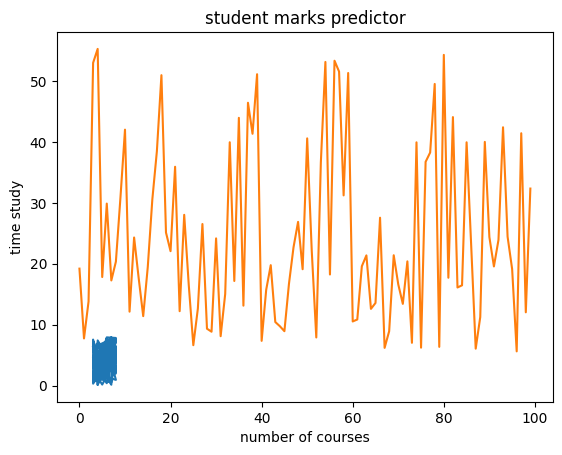

prediction: [20.76103324]


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df=pd.read_csv("sudent_data.csv")
print(df.columns)
x=df[["number_courses", "time_study"]]
y=df["Marks"]

plt.plot(df["number_courses"], df["time_study"], df["Marks"])
plt.title("student marks predictor")
plt.xlabel("number of courses")
plt.ylabel("time study")
plt.show()


model=LinearRegression()
model.fit(x, y)

prediction =model.predict([[5, 3.5]])
print("prediction:", prediction)